In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from astropy.table import Table

In [2]:
data = Table.read("Planet_Lightcurve.fits")
print(data.colnames)
print(data)

['time [days]', 'flux']
    time [days]             flux       
-------------------- ------------------
                -0.3 0.9718556446853187
 -0.2993993993993994  0.974430548606305
 -0.2987987987987988 0.9696244442016453
 -0.2981981981981982 0.9672472927361904
 -0.2975975975975976 0.9739989623419928
  -0.296996996996997 0.9689265223770298
-0.29639639639639637 0.9678268042192515
 -0.2957957957957958 0.9676453996308826
-0.29519519519519516 0.9703558446606856
 -0.2945945945945946 0.9738800653806102
                 ...                ...
  0.2945945945945945 0.9914653112446374
 0.29519519519519516 0.9978371225844164
  0.2957957957957958  1.000796759382211
  0.2963963963963964 0.9968976911446861
 0.29699699699699694 1.0017105738372651
  0.2975975975975976 1.0025198411286196
  0.2981981981981982 0.9930781407930032
 0.29879879879879884 0.9969834224859118
 0.29939939939939936 0.9998456765152839
                 0.3 0.9997001308741668
Length = 1000 rows


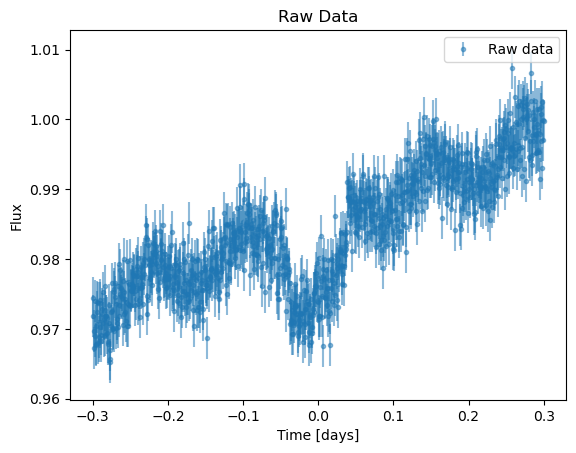

In [60]:
flux = data['flux']
time = data['time [days]']

x = time
y = flux

y_err = 0.003

plt.errorbar(x, y, yerr=y_err,label='Raw data', fmt='.', alpha=0.5)
plt.xlabel("Time [days]")
plt.ylabel("Flux")
plt.title("Raw Data")
plt.legend()
plt.show()

In [48]:
def line(x, m, b):
    return m*x+b

def curve(x, a, p, ph):
    '''
    Inputs:
            a = amplitude (vertical stretch)
            p = period ()
            ph = Phase shift (mode left and right)
    Returns:
    '''
    return (a*np.sin(p*(x-ph)))+1

In [61]:
ichoose = np.where((np.asarray(x) <= -0.1))[0]
ichoose = np.append(ichoose, np.where((np.asarray(x) >= 0.1))[0])

In [62]:
initial_guesses1 = [.038,0.985]
params, pcov  = curve_fit(line, x[ichoose], y[ichoose], sigma=y_err, p0=initial_guesses1)

m_fit = params[0]
b_fit = params[1]

print(m_fit, b_fit)

0.041156561177851915 0.9851536134299663


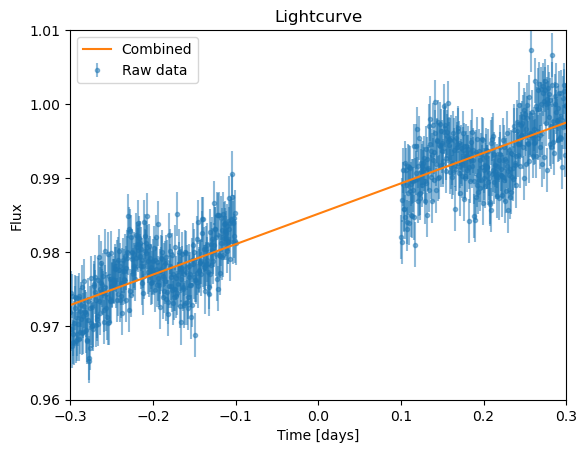

In [77]:
line_fit = line(x, m_fit, b_fit)

plt.errorbar(x[ichoose], y[ichoose], yerr= y_err,label='Raw data', fmt='.', zorder=1, alpha=0.5)
plt.xlim(-0.3,0.3)
plt.ylim(0.96, 1.01)
plt.xlabel("Time [days]")
plt.ylabel("Flux")
plt.title("Lightcurve")
plt.plot(x, line_fit, label = 'Combined', zorder=2)
plt.legend()

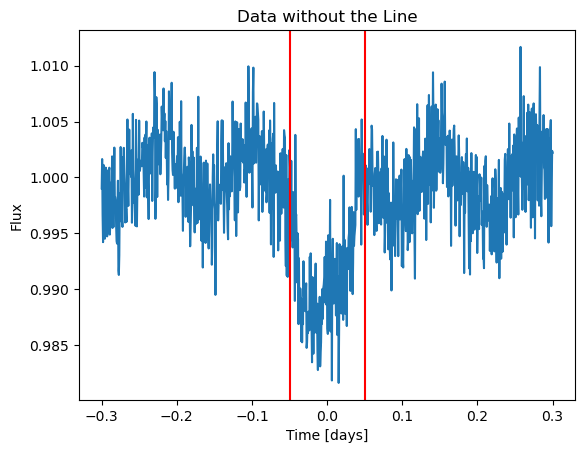

In [78]:
new_y = y/line_fit

plt.plot(x, new_y)
plt.xlabel("Time [days]")
plt.ylabel("Flux")
plt.title("Data without the Line")

#guessing the transit part
plt.axvline(-0.05, color='red')
plt.axvline(0.05, color='red')

Text(0.5, 1.0, 'Data without the Line')

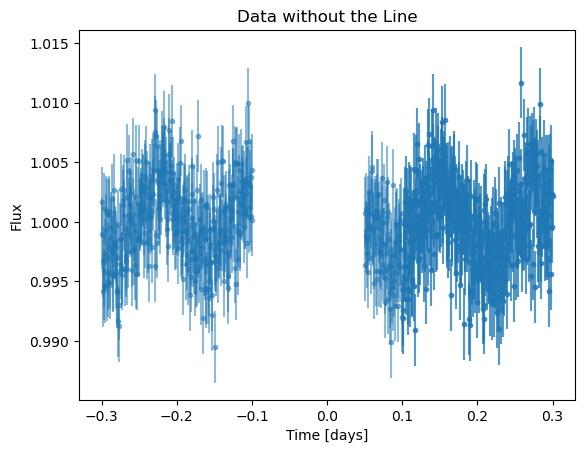

In [79]:
ichoose2 = np.where((np.asarray(x) <= -0.05))[0]
ichoose2 = np.append(ichoose, np.where((np.asarray(x) >= 0.05))[0])

plt.errorbar(x[ichoose2], new_y[ichoose2], yerr= y_err, label='Raw data', fmt='.', zorder=1, alpha=0.5)
plt.xlabel("Time [days]")
plt.ylabel("Flux")
plt.title("Data without the Line")

In [80]:
initial_guesses2 = [0.006, 50, 1.5]

params2, pcov2 = curve_fit(curve, x[ichoose2], new_y[ichoose2], sigma=y_err, p0=initial_guesses2)

a_fit = params2[0]
p_fit = params2[1]
ph_fit = params2[2]

print(a_fit, p_fit, ph_fit)

0.0027646385840570916 50.415007180361215 1.4906154306260684


Text(0.5, 1.0, 'Data Curve fit to Curve')

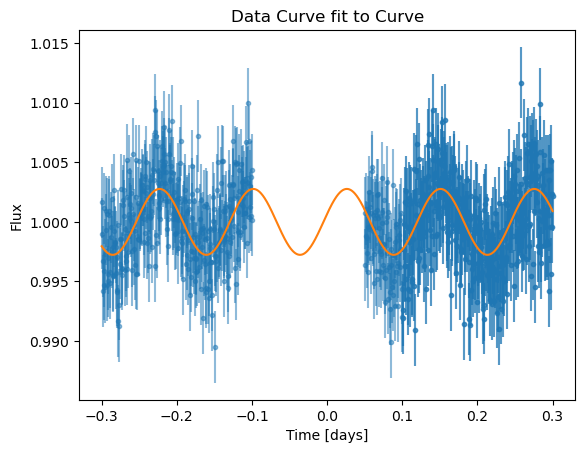

In [81]:
curve_fit = curve(x, a_fit, p_fit, ph_fit)

plt.errorbar(x[ichoose2], new_y[ichoose2], yerr= y_err, label='Raw data', fmt='.', zorder=1, alpha=0.5)
plt.plot(x, curve_fit, label = 'Curve', zorder=2)
plt.xlabel("Time [days]")
plt.ylabel("Flux")
plt.title("Data Curve fit to Curve")

Text(0.5, 1.0, 'Final Graph')

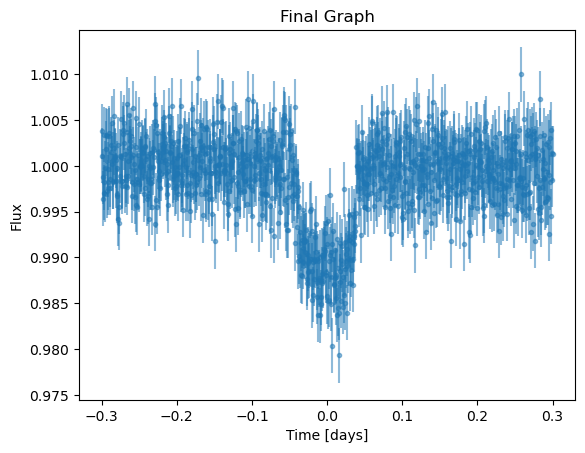

In [82]:
y_best = new_y/curve_fit

plt.errorbar(x, y_best, yerr=y_err, label='Final Graph', fmt='.', zorder=1, alpha=0.5)
plt.xlabel("Time [days]")
plt.ylabel("Flux")
plt.title("Final Graph")

In [83]:
params_err1 = np.sqrt(np.diag(pcov))
params_err2 = np.sqrt(np.diag(pcov2))

m_sigma = params_err1[0]
b_sigma = params_err1[1]

a_sigma = params_err2[0]
p_sigma = params_err2[1]
ph_sigma = params_err2[2]

print(f'm = {m_fit} ± {m_sigma}')
print(f'b = {b_fit} ± {b_sigma}')
print(f'a = {a_fit} ± {a_sigma}')
print(f'p = {p_fit} ± {p_sigma}')
print(f'ph = {ph_fit} ± {ph_sigma}')

m = 0.041156561177851915 ± 0.0006582559914394793
b = 0.9851536134299663 ± 0.00013713758163196388
a = 0.0027646385840570916 ± 0.0001306599836708217
p = 50.415007180361215 ± 0.26033522620467886
ph = 1.4906154306260684 ± 0.007403619067116212


## part 4

In [98]:
'''
found in part 2:
------------------
m_fit, m_sigma
b_fit, b_sigma

a_fit, a_sigma
p_fit, p_sigma
ph_fit, ph_sigma

line_fit

new_y = y/line_fit

curve_fit

y_best = new_y/curve_fit


'''

m=m_fit
b=b_fit
a=a_fit
p=p_fit
ph=ph_fit

detrended_flux = y_best

## error of line-fit (line_fit_sigma):

In [104]:
# line: mx + b

m_deriv = x
b_deriv = 1

line_fit_sigma = np.sqrt((m_deriv * m_sigma)**2 + (b_deriv * b_sigma)**2)

data_line_sigma = Table([x, line_fit, line_fit_sigma], names=['time[days]', 'line-fit', 'sigma of line-fit' ])  

print(data_line_sigma)

     time[days]           line-fit        sigma of line-fit   
-------------------- ------------------ ----------------------
                -0.3 0.9728066450766107 0.00024042421221624294
 -0.2993993993993994 0.9728313637319729 0.00024009959107421666
 -0.2987987987987988 0.9728560823873349 0.00023977518230581296
 -0.2981981981981982 0.9728808010426969  0.0002394509867742047
 -0.2975975975975976  0.972905519698059 0.00023912700534667683
  -0.296996996996997 0.9729302383534211  0.0002388032388946465
-0.29639639639639637 0.9729549570087832 0.00023847968829368327
 -0.2957957957957958 0.9729796756641452 0.00023815635442352953
-0.29519519519519516 0.9730043943195074 0.00023783323816812068
 -0.2945945945945946 0.9730291129748694 0.00023751034041560585
                 ...                ...                    ...
  0.2945945945945945 0.9972781138850633 0.00023751034041560583
 0.29519519519519516 0.9973028325404253 0.00023783323816812068
  0.2957957957957958 0.9973275511957874 0.0002381563544

## error of flux without linear artifact (new_y_sigma):

In [105]:
#divide out the linear artifacts
#new_y = y/line_fit

new_y_sigma = np.sqrt(((y_err/y)**2) + (line_fit_sigma/line_fit)**2) * new_y

data_new_y_sigma = Table([x,new_y, new_y_sigma], names=['time[days]', 'flux w/o line ', 'sigma of flux w/o line' ]) 
print(data_new_y_sigma)

     time[days]        flux w/o line    sigma of flux w/o line
-------------------- ------------------ ----------------------
                -0.3 0.9990224158149977   0.003093728641844987
 -0.2993993993993994 1.0016438459263868  0.0030936750785198826
 -0.2987987987987988 0.9966781950134296  0.0030934723763478833
 -0.2981981981981982 0.9942094568003924  0.0030933192968712405
 -0.2975975975975976  1.001123893966881  0.0030933492543138105
  -0.296996996996997 0.9958848889482897  0.0030931422960742126
-0.29639639639639637 0.9947293009274576     0.0030930152181644
 -0.2957957957957958 0.9945175874001463  0.0030929065207306967
-0.29519519519519516 0.9972779674230823   0.003092855077336732
 -0.2945945945945946 1.0008745395121212   0.003092819663965999
                 ...                ...                    ...
  0.2945945945945945 0.9941713323901383  0.0030174914996947437
 0.29519519519519516 1.0005357350110298   0.003017561616427269
  0.2957957957957958   1.00347850431111  0.003017568196

## error of curve-fit line (curve_fit_sigma)

In [106]:
# curve: asin(p(x-ph))+1

a_deriv = np.sin(p*(x-ph))
p_deriv = (x-ph)*a*np.cos(p*(x-ph))
ph_deriv = -p*a*np.cos(p*(x-ph))

curve_fit_sigma = np.sqrt((a_deriv * a_sigma)**2 + (p_deriv * p_sigma)**2 + (ph_deriv * ph_sigma)**2)

data_curve_fit_sigma = Table([x, curve_fit, curve_fit_sigma], names=['time[days]', 'curve-fit', 'sigma of curve-fit' ])  

print(data_curve_fit_sigma)

     time[days]          curve-fit        sigma of curve-fit 
-------------------- ------------------ ---------------------
                -0.3 0.9979556058296316 0.0011156007826764803
 -0.2993993993993994  0.997900198895823 0.0010782948223358683
 -0.2987987987987988 0.9978467169861067 0.0010400500868103055
 -0.2981981981981982  0.997795209130824 0.0010009059299942627
 -0.2975975975975976 0.9977457225505721 0.0009609032483098375
  -0.296996996996997 0.9976983026129144 0.0009200846238600299
-0.29639639639639637 0.9976529927907881 0.0008784945228748741
 -0.2957957957957958 0.9976098346226512 0.0008361795711724623
-0.29519519519519516 0.9975688676744002 0.0007931889384468308
 -0.2945945945945946 0.9975301295030983 0.0007495748788501937
                 ...                ...                   ...
  0.2945945945945945  1.001577281030455 0.0011061696518190303
 0.29519519519519516  1.001507817818453 0.0011283803376119447
  0.2957957957957958 1.0014369722918968 0.0011495670630943685
  0.2963

## error of detrended_flux (detrended_flux_sigma):

In [107]:
#divide out the curve artifacts
#detrended_flux = new_y/curve_fit

detrended_flux_sigma = np.sqrt((new_y_sigma/new_y)**2 + (curve_fit_sigma/curve_fit)**2) * detrended_flux

data_detrended_flux_sigma = Table([x,detrended_flux, detrended_flux_sigma], names=['time[days]', 'detrended flux', 'sigma of detrended flux' ])  

print(data_detrended_flux_sigma)

     time[days]        detrended flux   sigma of detrended flux
-------------------- ------------------ -----------------------
                -0.3 1.0010689954333982      0.0032958692948775
 -0.2993993993993994 1.0037515244858215    0.003284439273421584
 -0.2987987987987988 0.9988289564391146    0.003270283111707408
 -0.2981981981981982 0.9964063243663446    0.003257296966004547
 -0.2975975975975976 1.0033858039578192   0.0032474452868138095
  -0.296996996996997 0.9981824027765955   0.0032340535474336724
-0.29639639639639637 0.9970694300679117    0.003222213245494369
 -0.2957957957957958 0.9969003440872508    0.003210944768678864
-0.29519519519519516 0.9997083908081493   0.0032006693389136686
 -0.2945945945945946 1.0033526907209198   0.0031908307956307488
                 ...                ...                     ...
  0.2945945945945945 0.9926057142263678   0.0032059925612970062
 0.29519519519519516 0.9990293807096376    0.003216399985549293
  0.2957957957957958 1.0020386026037575 